## Dependencia temporal

**Objetivo:** medir o quanto a serie depende dos seus proprios valores passados. Isso ajuda a responder se existe memoria curta, padrao semanal e recorrencia anual.

Nesta etapa vamos analisar:
- **ACF** para medir a autocorrelacao em diferentes lags;
- **PACF** para identificar defasagens com dependencia mais direta;
- **lag plots** para visualizar a relacao entre a serie atual e seus atrasos;
- uma tabela de correlacao nas defasagens **t-1**, **t-7**, **t-14**, **t-30** e **t-365**.

Como a serie tem tendencia forte, e esperado que a ACF da serie bruta fique elevada em varios lags. Ainda assim, esse bloco e util para mostrar a memoria temporal observada da serie.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [2]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.csv"

df_internacoes = pd.read_csv(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

# Dependencia temporal

In [3]:
serie_dependencia = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_dependencia = int(serie_dependencia.isna().sum())
if faltantes_dependencia > 0:
    print(f"Foram encontrados {faltantes_dependencia} dias faltantes. A serie sera interpolada para a analise de dependencia temporal.")
    serie_dependencia = serie_dependencia.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a analise de dependencia temporal.")

lags_interesse = [1, 7, 14, 30, 365]
df_lags = pd.DataFrame(index=serie_dependencia.index)
df_lags["num_internacoes"] = serie_dependencia

for lag in lags_interesse:
    df_lags[f"lag_{lag}"] = serie_dependencia.shift(lag)

display(df_lags.head(10))

Nenhum dia faltante foi encontrado para a analise de dependencia temporal.


,num_internacoes,lag_1,lag_7,lag_14,lag_30,lag_365
data_dia,,,,,,
2012-01-01,546,NaN,NaN,NaN,NaN,NaN
2012-01-02,784,546.0,NaN,NaN,NaN,NaN
2012-01-03,462,784.0,NaN,NaN,NaN,NaN
2012-01-04,448,462.0,NaN,NaN,NaN,NaN
2012-01-05,434,448.0,NaN,NaN,NaN,NaN
2012-01-06,560,434.0,NaN,NaN,NaN,NaN
2012-01-07,322,560.0,NaN,NaN,NaN,NaN
2012-01-08,420,322.0,546.0,NaN,NaN,NaN
2012-01-09,476,420.0,784.0,NaN,NaN,NaN


### ACF e PACF

A **ACF** mostra a persistencia global da serie ao longo das defasagens. A **PACF** ajuda a destacar quais lags ainda guardam informacao mais direta depois de controlar os anteriores.

Usamos dois alcances diferentes na ACF:
- um recorte curto, para enxergar a memoria imediata;
- um recorte mais longo, para verificar sinais de padrao semanal e anual.

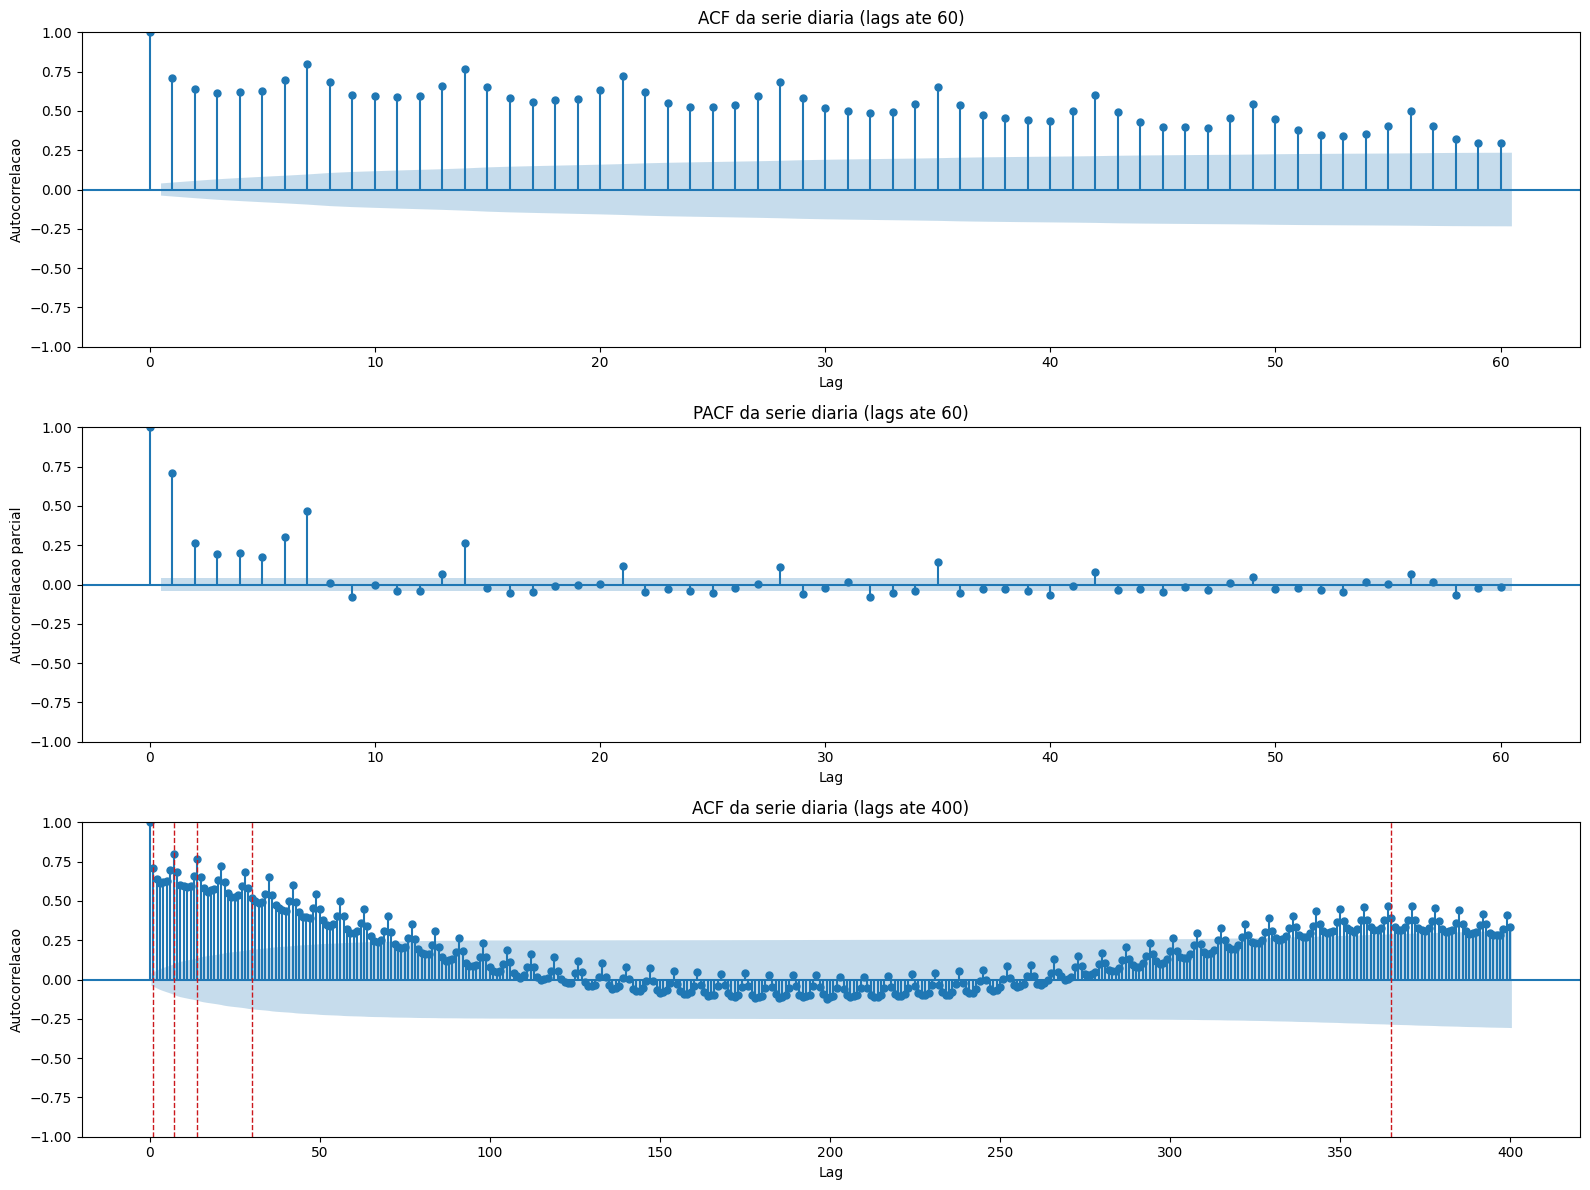

In [4]:
lags_acf_curto = 60
lags_acf_longo = 400
lags_pacf = 60

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

plot_acf(serie_dependencia, lags=lags_acf_curto, ax=axes[0], alpha=0.05, fft=True)
axes[0].set_title("ACF da serie diaria (lags ate 60)")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelacao")

plot_pacf(serie_dependencia, lags=lags_pacf, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF da serie diaria (lags ate 60)")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelacao parcial")

plot_acf(serie_dependencia, lags=lags_acf_longo, ax=axes[2], alpha=0.05, fft=True)
axes[2].set_title("ACF da serie diaria (lags ate 400)")
axes[2].set_xlabel("Lag")
axes[2].set_ylabel("Autocorrelacao")

for lag_marcado in lags_interesse:
    if lag_marcado <= lags_acf_longo:
        axes[2].axvline(lag_marcado, color="#cb181d", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

### Lag plots

Os lag plots mostram a relacao entre o valor atual da serie e um valor atrasado. Quanto mais alinhados e concentrados os pontos em torno de uma diagonal crescente, maior tende a ser a dependencia temporal naquele lag.

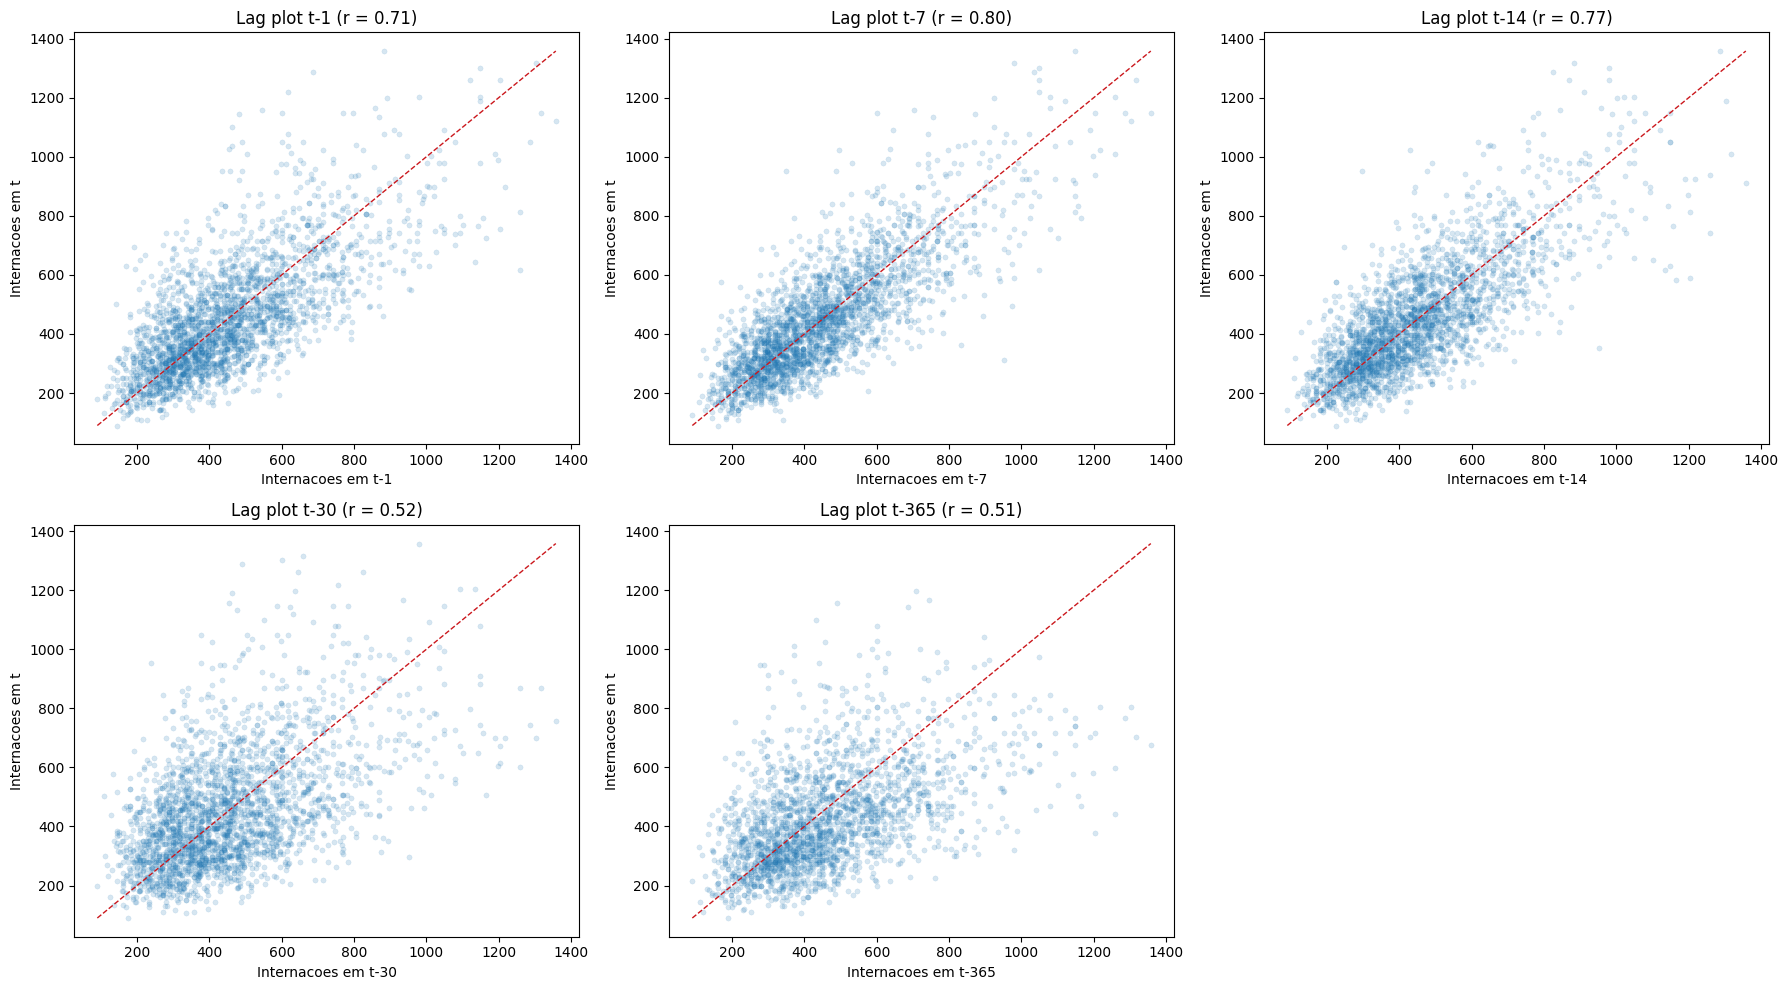

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, lag in enumerate(lags_interesse):
    dados_plot = df_lags[["num_internacoes", f"lag_{lag}"]].dropna()
    correlacao_lag = dados_plot["num_internacoes"].corr(dados_plot[f"lag_{lag}"])

    sns.scatterplot(
        data=dados_plot,
        x=f"lag_{lag}",
        y="num_internacoes",
        alpha=0.18,
        s=14,
        edgecolor=None,
        ax=axes[i],
    )

    menor_valor = min(dados_plot["num_internacoes"].min(), dados_plot[f"lag_{lag}"].min())
    maior_valor = max(dados_plot["num_internacoes"].max(), dados_plot[f"lag_{lag}"].max())
    axes[i].plot([menor_valor, maior_valor], [menor_valor, maior_valor], color="#cb181d", linestyle="--", linewidth=1)
    axes[i].set_title(f"Lag plot t-{lag} (r = {correlacao_lag:.2f})")
    axes[i].set_xlabel(f"Internacoes em t-{lag}")
    axes[i].set_ylabel("Internacoes em t")

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Correlacao nas defasagens de interesse

Esta tabela resume a forca da dependencia temporal nos lags mais relevantes para a serie. Alem da correlacao de Pearson entre `t` e `t-k`, tambem registramos o valor correspondente da ACF para o mesmo lag.

,lag,correlacao_pearson,autocorrelacao_acf,n_observacoes
0,1,0.712,0.712,2556
1,7,0.802,0.800,2550
2,14,0.770,0.766,2543
3,30,0.521,0.516,2527
4,365,0.514,0.392,2192


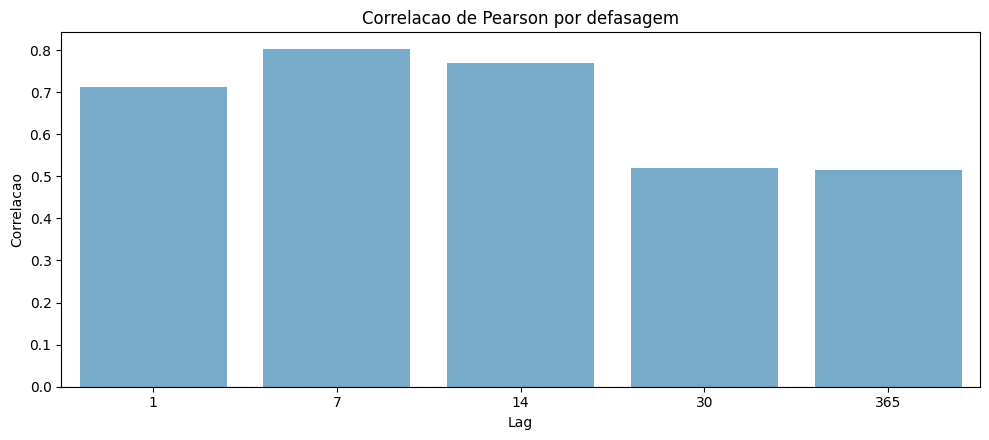

In [6]:
acf_valores = acf(serie_dependencia, nlags=max(lags_interesse), fft=True)

resumo_lags = []
for lag in lags_interesse:
    dados_lag = df_lags[["num_internacoes", f"lag_{lag}"]].dropna()
    resumo_lags.append(
        {
            "lag": lag,
            "correlacao_pearson": dados_lag["num_internacoes"].corr(dados_lag[f"lag_{lag}"]),
            "autocorrelacao_acf": acf_valores[lag],
            "n_observacoes": len(dados_lag),
        }
    )

resumo_lags = pd.DataFrame(resumo_lags)
display(resumo_lags.round(3))

plt.figure(figsize=(10, 4.5))
sns.barplot(data=resumo_lags, x="lag", y="correlacao_pearson", color="#6baed6")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Correlacao de Pearson por defasagem")
plt.xlabel("Lag")
plt.ylabel("Correlacao")
plt.tight_layout()
plt.show()

### Resumo interpretativo dos resultados

A analise de dependencia temporal mostrou que a serie possui **persistencia relevante no curto prazo** e um **padrao semanal muito marcado**. A correlacao em **t-1** foi alta (**0,712**), mas a maior relacao apareceu em **t-7 (0,802)**, seguida de **t-14 (0,770)**. Isso indica que o valor de uma semana antes explica a serie atual com mais forca do que o dia imediatamente anterior.

A **ACF** confirmou esse comportamento. Alem de permanecer elevada nos primeiros lags, ela apresentou picos claros em multiplos de 7, com destaque para **7 (0,800)** e **14 (0,766)**, o que e tipico de uma serie com **recorrencia semanal consistente**. Esse desenho reforca o que ja havia aparecido na analise de sazonalidade e na decomposicao.

A **PACF** ajuda a refinar essa leitura. O maior efeito direto continuou aparecendo no **lag 1**, como esperado, mas o padrao visual tambem mostrou relevancia para defasagens ligadas ao ciclo semanal. Isso sugere que, mesmo depois de controlar os atrasos mais proximos, a serie ainda guarda informacao adicional em lags associados ao calendario semanal.

Em horizontes mais longos, a dependencia continua, mas enfraquece gradualmente. A correlacao em **t-30** ainda foi relevante (**0,521**), enquanto em **t-365** permaneceu em um patamar **moderado** (**0,514** na correlacao de Pearson e **0,392** na ACF). Isso sugere que existe **recorrencia anual presente**, embora menos intensa do que a memoria curta e o padrao semanal mais imediato.

Outro ponto importante e que a ACF decai de forma relativamente lenta, inclusive em lags mais longos. Isso e coerente com a evidencia anterior de tendencia e sazonalidade fortes, e indica que a serie bruta provavelmente nao e estacionaria. Em outras palavras, parte da alta autocorrelacao observada nao vem apenas de memoria temporal pura, mas tambem da estrutura de tendencia e de calendario que ja identificamos.

**Possiveis analises e consequencias**
- Os lags **1**, **7** e **14** devem ser considerados candidatos prioritarios para features em modelos de previsao.
- O sinal ainda presente em **30 dias** sugere utilidade de memoria de medio prazo, especialmente em modelos baseados em lags ou janelas moveis.
- O lag **365** pode entrar como complemento em modelos com recorrencia anual, mas com peso menor do que os lags curtos e semanais.
- Como a ACF da serie bruta permanece alta por muito tempo, vale repetir essa analise depois em uma versao diferenciada, detrendida ou dessazonalizada para separar memoria real de nao estacionariedade.
- A combinacao de memoria curta forte e padrao semanal claro sugere que modelos autoregressivos, modelos com lags explicitos e features de calendario podem capturar bem uma parte importante da dinamica da serie.